## Environment

In [95]:
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import DataLoader
import os
import numpy as np
from torch.utils.data import Subset


In [96]:
from Utils.utils import get_system_info


get_system_info()

===== System Info =====
OS: Linux 5.15.167.4-microsoft-standard-WSL2
Python Version: 3.11.14
CPU: x86_64
RAM: 27.41 GB

===== PyTorch Info =====
PyTorch Version: 2.4.0+cu118
CUDA Available: True
CUDA Version (PyTorch): 11.8
GPU Count: 1
GPU 0: NVIDIA GeForce RTX 4070, 11.99 GB VRAM


## Distribution Shift (DS)

Distribution Shift는 학습 데이터와 테스트 데이터의 분포가 다른 상황을 의미한다.  
모델은 보통 학습 분포에서는 잘 동작하지만, 분포가 달라지면 성능이 크게 저하될 수 있다.

---

## Why DS in this PoC?

이 실험의 목적은 단순 accuracy가 아니라,  
모델이 어떤 feature에 의존하는지(OOD 상황에서 더 드러나는지)를 분석하는 것이다.

clean ImageNet에서는 여러 feature가 동시에 유효하기 때문에 reliance 차이가 잘 드러나지 않지만,  
distribution shift가 발생하면 특정 feature가 깨지면서 모델의 의존 구조가 성능 변화로 나타난다.

---

## Setup

### Data
- **ID** ImageNet (Original)
- **Shifted / OOD**:
  feature-level 변화를 유도하는 데이터 또는 변환을 사용한다. 예를 들어,
  - Stylized-ImageNet (texture 변화)
  - ImageNet-R (Natural Domain Shift)
  - feature-targeted intervention (e.g., suppression, filtering)
  - 기타 controlled perturbations (e.g., color, blur)

### Model
- Resnet-50 (ImageNet Pretrained)
- Vit-B (ImageNet Pretrained)
- DINO-v2 (Vit-B)

---

## Experimental Design

동일한 모델에 대해 다음 세 가지 유형의 분포에서 비교를 수행한다:

- **A (ID)**: ImageNet (original)
- **C (Natural Shift)**: ImageNet-R
- **D (Synthetic / Controlled Shift)**: Stylized-ImageNet

각 분포에 대해, 동일한 feature-targeted intervention을 적용한 경우를 함께 비교한다:

- **A'**: ID + intervention  
- **C'**: Natural shift + intervention  
- **D'**: Controlled shift + intervention  

---

## Comparison Strategy

핵심은 intervention이 각 분포에서 미치는 영향을 비교하는 것이다:

- **Δ_ID = (A' - A)**
- **Δ_Natural = (C' - C)**
- **Δ_Controlled = (D' - D)**

이를 통해 다음을 확인한다:

- intervention이 단순한 성능 저하인지
- 특정 feature reliance를 건드리는 효과인지
- 그 효과가 distribution shift에서 더 크게 나타나는지

---

## Interpretation

- Reliane Score가  
  해당 feature가 OOD 환경에서 더 중요한 역할을 한다고 해석할 수 있다.

- 서로 다른 shift (natural vs controlled)에서 일관된 패턴이 나타날 경우,  
  특정 dataset이나 perturbation에 의존하지 않는 현상일 가능성이 높다.

---

추후 DINO-v2 같이 더 큰 DS로 학습된 것에서도 같은 반응이 나온다고 같은 결론에 이르는 것은 논리적 비약이 아닌지 생각해 봐야 함

# Dataset Load
1. Imagenet Val -> HF
2. Stylized Imagenet
3. ImageNet - R

In [97]:
from huggingface_hub import whoami
print(whoami(token=True))

{'type': 'user', 'id': '67b7b2215ca6113f963198bd', 'name': 'sasasassaszzd', 'fullname': '김동찬', 'isPro': False, 'avatarUrl': '/avatars/cdd9a6c94ba7d1da543494f2a16a8955.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'DONGCHAN KIM', 'role': 'fineGrained', 'createdAt': '2025-07-02T04:00:30.500Z', 'fineGrained': {'canReadGatedRepos': True, 'global': [], 'scoped': [{'entity': {'_id': '67b7b2215ca6113f963198bd', 'type': 'user', 'name': 'sasasassaszzd'}, 'permissions': ['repo.content.read', 'repo.write']}]}}}}


In [98]:
from datasets import load_dataset
from torchvision.datasets import ImageFolder
from Utils.Dataset import ImageNetValFlatDataset, UnifiedDataset
from Utils.transfrom import get_transform

RESIZED_IMG_SIZE = 256
imgnet_1k_mean = [0.4850, 0.4560, 0.4060]
imgnet_1k_std = [0.2290, 0.2240, 0.2250]

imagenet_1k_transform = get_transform(test_augmentations="resizecrop", resize_size=RESIZED_IMG_SIZE, mean=imgnet_1k_mean, std=imgnet_1k_std, split="test")
imagenet_1k_val = ImageNetValFlatDataset(transform=imagenet_1k_transform)

print("Number of Sample: ", len(imagenet_1k_val))
print("Number of Class: ", imagenet_1k_val.class_num)
print("Shape of IMG: ", imagenet_1k_val[0][0].shape)

print()
print("Transform: ", imagenet_1k_transform)
# Stylized는 찾아봐야 함

Number of Sample:  50000
Number of Class:  1000
Shape of IMG:  torch.Size([3, 224, 224])

Transform:  Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


# 1. Data 예시 

tensor([[[0.4850]],

        [[0.4560]],

        [[0.4060]]]) tensor([[[0.2290]],

        [[0.2240]],

        [[0.2250]]])


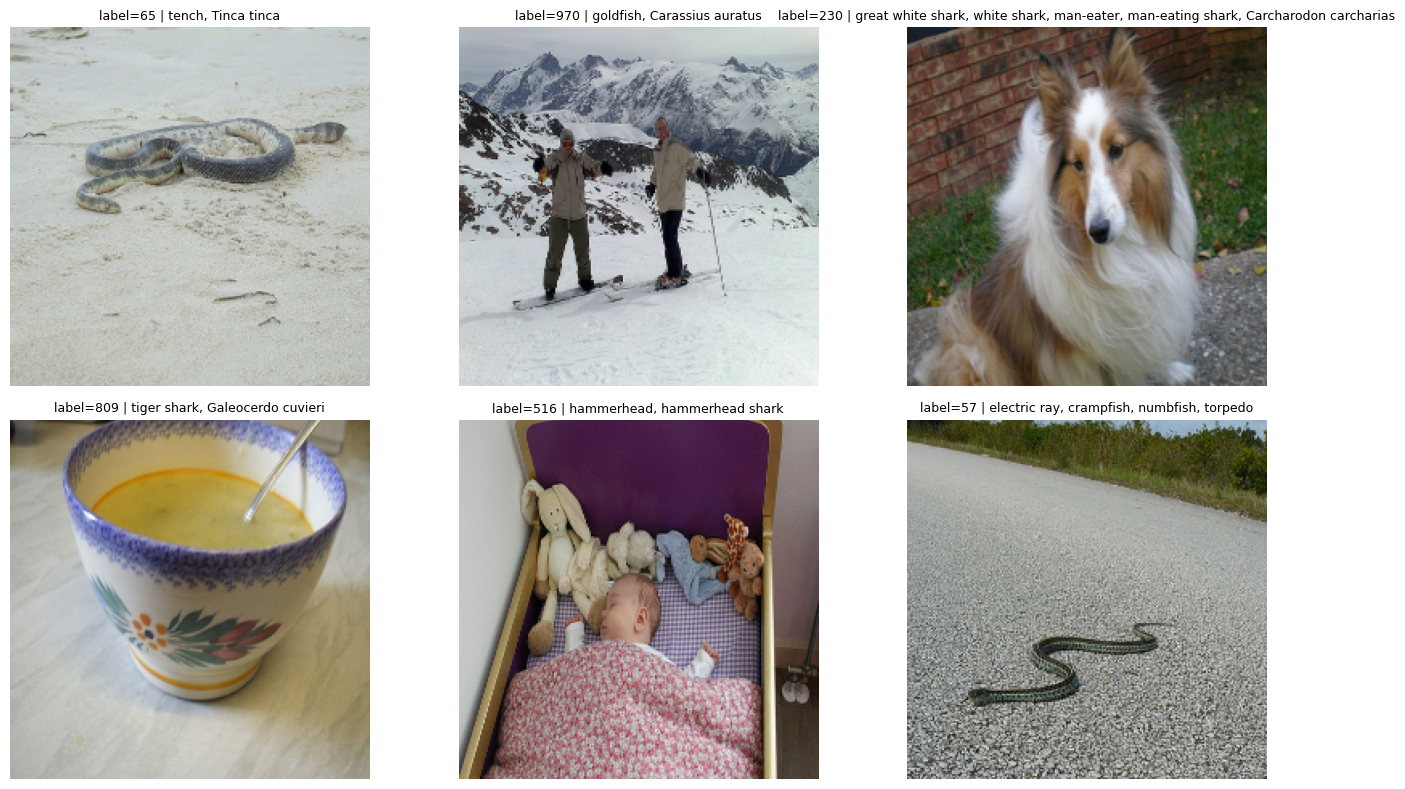

In [99]:
# Visualize image
import matplotlib.pyplot as plt
import torch
from timm.data import ImageNetInfo

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
print(mean, std)
info = ImageNetInfo()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, ax in enumerate(axes.flat):
    image, label = imagenet_1k_val[i]

    image = image.float().cpu()
    image = image * std + mean
    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0)

    label = int(label)
    class_name = imagenet_1k_val.index_to_description(i)

    ax.imshow(image)
    ax.set_title(f"label={label} | {class_name}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 2. Data Suppersion Example

후에는 설정을 바구어가면서 실험을 진행해야 함

## HyperParmas

In [100]:
# Texture (Bilateral)
bilateral_d = 11
sigma_color=170 
sigma_space=75

#Gaussian Blur
gaussian_k=11
gaussian_sigma=2.0
nlmeans_h=20
template_window_size=11
search_window_size=11

# Color (Gray Scale)
gray_alpha = 1.0

# Shape (PatchSuffle, rotate) 
grid_size=6

# Shape (localwarp)
alpha_localwarp = 35.0
sigma_localwarp = 2.5

BS = 512
RESIZE_IMG_SIZE = 224

transform_name: grayscale, Shape (224, 224, 3)
transform_name: channelshuffle, Shape (224, 224, 3)
transform_name: bilateral, Shape (224, 224, 3)
transform_name: gaussianblur, Shape (224, 224, 3)
transform_name: patchshuffle, Shape (224, 224, 3)
transform_name: patchrotation, Shape (224, 224, 3)
transform_name: localwarp, Shape (224, 224, 3)


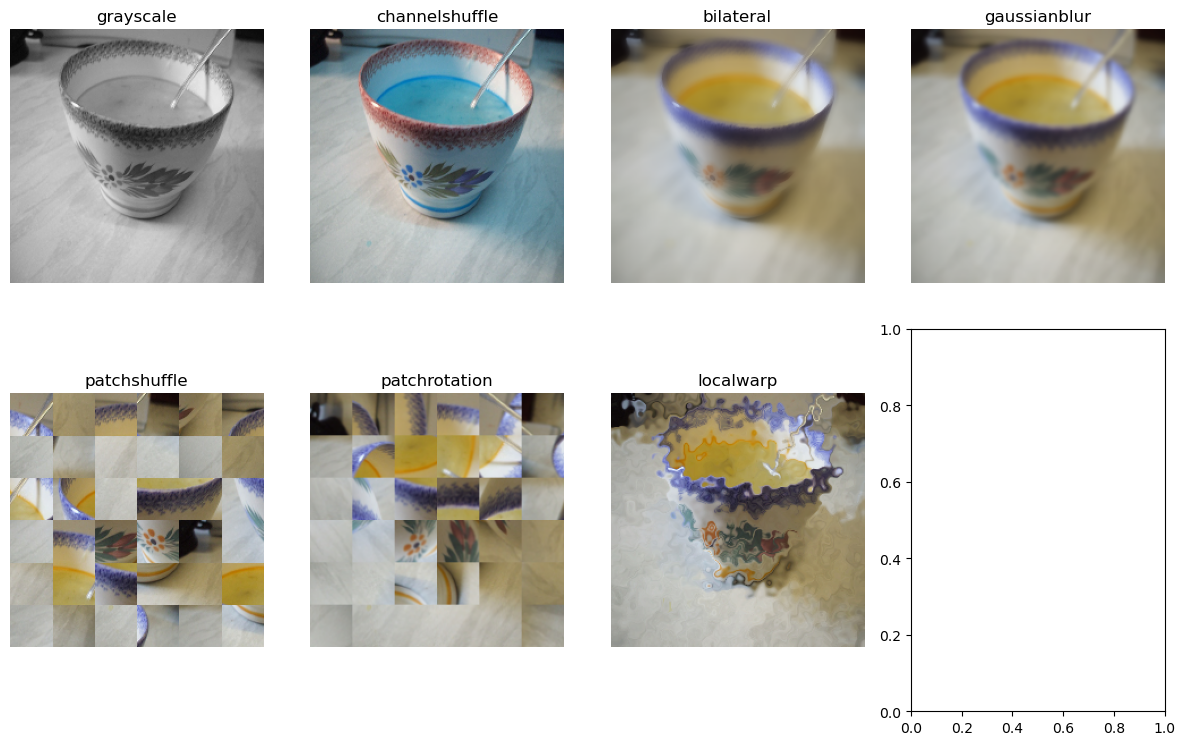

In [101]:
# Visualize image

import matplotlib.pyplot as plt
import torch

transform_names = [
    "grayscale",
    "channelshuffle",
    "bilateral",
    "gaussianblur",
    "patchshuffle",
    "patchrotation",
    "localwarp"
]

imagenet_1k_val_no_transform = ImageNetValFlatDataset("Data", transform=None)
image, label = imagenet_1k_val_no_transform[3]

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

for ax, transform_name in zip(axes, transform_names):
    
    resized_transform_name = "resizecrop_" + transform_name
    t = get_transform(
        train_augmentations=resized_transform_name,
        p=1.0,
        resize_size=RESIZE_IMG_SIZE,
        gray_alpha=gray_alpha,
        bilateral_d=bilateral_d,
        sigma_color=sigma_color,
        sigma_space=sigma_space,
        gaussian_k=gaussian_k,
        gaussian_sigma=gaussian_sigma,
        nlmeans_h=nlmeans_h,
        template_window_size=template_window_size,
        search_window_size=search_window_size,
        grid_size=grid_size,
        alpha_localwarp = alpha_localwarp,
        sigma_localwarp = sigma_localwarp,
        split="train",
        normalize=False
    )
    img_t:np.ndarray = t(image.copy())
    print(f"transform_name: {transform_name}, Shape {img_t.shape}")

    ax.imshow(img_t)
    ax.set_title(transform_name)
    ax.axis("off")
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Feature 분리도 Test

In [ ]:
from Utils.metric import compute_dataset_metrics
import albumentations as A

max_samples = None
prefix = "resizecrop"

# TODO 그냥 get_transform쓰게 수정
base_ds = ImageNetValFlatDataset()
base_transform = get_transform("resizecrop", normalize=False)
transforms = dict()

for transform_name in transform_names:
    transforms[transform_name] = get_transform(
            train_augmentations=f"{prefix}_{transform_name}",
            p=1.0,
            resize_size=RESIZE_IMG_SIZE,
            gray_alpha=gray_alpha,
            bilateral_d=bilateral_d,
            sigma_color=sigma_color,
            sigma_space=sigma_space,
            gaussian_k=gaussian_k,
            gaussian_sigma=gaussian_sigma,
            nlmeans_h=nlmeans_h,
            template_window_size=template_window_size,
            search_window_size=search_window_size,
            grid_size=grid_size,
            alpha_localwarp = alpha_localwarp,
            sigma_localwarp = sigma_localwarp,
            split="train",
            normalize=False
        )
    
transform_names = [
    "grayscale",
    "channelshuffle",
    "bilateral",
    "gaussianblur",
    "patchshuffle",
    "patchrotation",
    "localwarp"
]

localwarp_result = compute_dataset_metrics(base_ds, base_transform, transforms['localwarp'], max_samples)
patchshuffle_result = compute_dataset_metrics(base_ds, base_transform, transforms['patchshuffle'], max_samples)
patchrotation_result = compute_dataset_metrics(base_ds, base_transform, transforms['patchrotation'], max_samples)
grayscale_result = compute_dataset_metrics(base_ds, base_transform, transforms['grayscale'], max_samples)
bilateral_result = compute_dataset_metrics(base_ds, base_transform, transforms['bilateral'], max_samples)

del base_ds

100%|██████████| 50000/50000 [11:55<00:00, 69.86it/s] 


In [103]:
def print_result(transform_name:str, result:dict):
    print("="*15 + " " + transform_name + " " +"="*15)
    for k,v in result.items():
        print(f"{k}: {v}")
        
    print("="*40)
    print()
    

transform_dict = {
    "Loacal warp": localwarp_result,
    "Patch shuffle": patchshuffle_result,
    "Patch rotate": patchrotation_result,
    "Gray Scale": grayscale_result,
    "Bilateral": bilateral_result,
}

for k,v in transform_dict.items():
    print_result(transform_name=k, result=v)

=============== Loacal warp ===============
LV_ratio: 0.9493680645598248
HFE_ratio: 0.9633452574301083
ESSIM: 0.30249658306952965
GC: 0.10422657349478952
texture_score: 0.9563566609949665
shape_score: 0.20336157828215962

=============== Patch shuffle ===============
LV_ratio: 0.9999699849282656
HFE_ratio: 0.9999966112409704
ESSIM: 0.22489012325954677
GC: 0.09445795070995827
texture_score: 0.999983298084618
shape_score: 0.15967403698475252

=============== Patch rotate ===============
LV_ratio: 0.9243025025878192
HFE_ratio: 0.913666317742698
ESSIM: 0.3653971451901791
GC: 0.21126584851089095
texture_score: 0.9189844101652586
shape_score: 0.28833149685053505

=============== Gray Scale ===============
LV_ratio: 0.9244351957762322
HFE_ratio: 0.913861966754678
ESSIM: 0.364762803823213
GC: 0.21022317448337194
texture_score: 0.9191485812654552
shape_score: 0.2874929891532925

=============== Bilateral ===============
LV_ratio: 0.5297290604482366
HFE_ratio: 0.4684375152351519
ESSIM: 0.5439440

# Experiment

## 1. Model: ViT-B, ResNet 50 -> 대표격인 모델들이라 선정 하지만 후에는 이유를 만들어 내야함
## 2. Dataset: 
### Data
- **ID** ImageNet (Original) -> 후에 Dino V2도 이걸로 학습이 되었는지 확인
- **Shifted / OOD**:
  OOD Benchmark
  - Stylized-ImageNet (texture 변화)
  - ImageNet-R (Natural Domain Shift)
- **controlled probe/intervention**
  - feature-targeted intervention (e.g., suppression, filtering)
  - 기타 controlled perturbations (e.g., color, blur)

## 3. Progress

### Step 1: Linear Probing 학습
### Step 2: Feature Reliance Measurement
### Step 3: Feature Realiance Patter 관측 (Feature Reliance Measurement)
### Step 4: Correlation Analysis (PoC 수준) -> ImagetNet-1k -> ImageNet - R로 Domain-shift 될 시 얼마나 각 Intervention에 따라 얼마나 성능이 하락하는지
    -> `np.corref`를 통해 분석 or spearman score X:각 intervention에 대한 feature reliance score y: 각 intervention에 대한 OOD accuracy drop
### Step 5: 나온 Insight에 맞는 Intervention을 가했을 시 OOD 성능이 향상되는지 -> 이 InterVention은 정해봐야 함


# Model Load
**ViT-B, ResNet50 -> timm**

In [104]:
import timm
import timm

# TODO 후에 Model Recipe에 대한 내용 명시
""
model = timm.create_model("vit_base_patch16_224.augreg_in1k", pretrained=True)
print(model.default_cfg)

{'url': 'https://storage.googleapis.com/vit_models/augreg/B_16-i1k-300ep-lr_0.001-aug_strong2-wd_0.1-do_0.1-sd_0.1--imagenet2012-steps_20k-lr_0.01-res_224.npz', 'hf_hub_id': 'timm/vit_base_patch16_224.augreg_in1k', 'architecture': 'vit_base_patch16_224', 'tag': 'augreg_in1k', 'custom_load': True, 'input_size': (3, 224, 224), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 0.9, 'crop_mode': 'center', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'num_classes': 1000, 'pool_size': None, 'first_conv': 'patch_embed.proj', 'classifier': 'head', 'license': 'apache-2.0'}


* Label Sanity Check

In [105]:
import timm
from timm.data import resolve_model_data_config, create_transform, ImageNetInfo

In [106]:
official_ds = ImageNetValFlatDataset()

print("="*15 + " Hugging Face Labels " + "="*15)
print(f"Index 0  : {official_ds.index_to_description(0)}")
print(f"Index 1  : {official_ds.index_to_description(1)}")
print(f"Index 999: {official_ds.index_to_description(999)}")
print()

# 2. timm 모델의 기준 라벨 확인
timm_info = ImageNetInfo()

print("="*15 + " timm (PyTorch) Labels " + "="*15)
print(f"Index 0  : {timm_info.index_to_description(0)}")
print(f"Index 1  : {timm_info.index_to_description(1)}")
print(f"Index 999: {timm_info.index_to_description(999)}")

same = True
for i in range(1000):
    hf_name = official_ds.index_to_description(i)
    timm_name = timm_info.index_to_description(i)

    if hf_name != timm_name:
        print(f"[Mismatch @ {i}]")
        print("HF   :", hf_name)
        print("timm :", timm_name)
        print()
        same = False

print("All same?", same)


=============== Hugging Face Labels ===============
Index 0  : tench, Tinca tinca
Index 1  : goldfish, Carassius auratus
Index 999: toilet tissue, toilet paper, bathroom tissue

=============== timm (PyTorch) Labels ===============
Index 0  : tench, Tinca tinca
Index 1  : goldfish, Carassius auratus
Index 999: toilet tissue, toilet paper, bathroom tissue
All same? True


In [107]:


vit = timm.create_model('vit_base_patch16_224.augreg_in1k', pretrained=True)
vit.eval()
vit_config = resolve_model_data_config(vit)
vit_transform = create_transform(**vit_config, is_training=False)

print("="*15 + " ViT-B Config and Transform " + "="*15)
print(vit_config)
print(vit_transform)
print("="*15  + "="*15 + "="*26)
print()


resnet = timm.create_model('resnet50', pretrained=True)
resnet.eval()
resnet_config = resolve_model_data_config(resnet)
resnet_transform = create_transform(**resnet_config, is_training=False)

print("="*15 + " ResNet50 Config and Transform " + "="*15)
print(resnet_config)
print(resnet_transform)
print("="*15  + "="*15 + "="*26)
print()

vit_mean = [0.5, 0.5, 0.5]
vit_std = [0.5, 0.5, 0.5]
resnet_mean = [0.485, 0.456, 0.406]
resnet_std = [0.229, 0.224, 0.225]

resnet_transform = get_transform("resizecrop", mean=resnet_mean, std=resnet_std)
vit_transform = get_transform("resizecrop", mean=vit_mean, std=vit_std)

# representaion끼리 비교를 위해서라면 같은 geometic 변환을 거쳐야 함 -> 같은 resize후 center crop

print()
print("Unified Transform: ")
print(resnet_transform)
print(vit_transform)

=============== ViT-B Config and Transform ===============
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}
Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.5000, 0.5000, 0.5000]), std=tensor([0.5000, 0.5000, 0.5000]))
)

=============== ResNet50 Config and Transform ===============
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.95, 'crop_mode': 'center'}
Compose(
    Resize(size=235, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


Unified Transform: 
Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]

In [108]:
# Model Architerture

print(resnet)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

In [109]:
print(vit)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

**Step 1: Standardized classifier setup** 
* **Representation Vector**를 만들어 반복학습 -> L2 Regularzation, Early-stopping을 통해 Overfitting 제한 후에 val, train acc gap비교

In [110]:
# 현재 PoC실험에서는 생략

**Step2: Feature Reliance Measurement**
* 위에서 있는 Perturbation 도구로 실험 진행 -> 완전한 feature분리가 되지 않음을 명시


**`Metric`** -> 후에 relative Margin Gap도입 max와 두번째 max간의 margin을 비교한 지표
* prediction change
    * Δlogit
* KL / JS divergence
* representation change
    * CKA distance or feature similarity drop
* performance change
* accuracy drop on perturbed input

In [111]:
prefix = "resizecrop"
resnet_transforms = {
    "texture": get_transform(f"{prefix}_bilateral", p=1.0, bilateral_d=bilateral_d, sigma_color=sigma_color, sigma_space=sigma_space, mean=resnet_mean, std=resnet_std),
    "color": get_transform(f"{prefix}_grayscale", p=1.0, gray_alpha=gray_alpha,mean=resnet_mean, std=resnet_std),
    "shape1": get_transform(f"{prefix}_patchshuffle", p=1.0, grid_size=grid_size, mean=resnet_mean, std=resnet_std),
    "shape2": get_transform(f"{prefix}_patchrotation", p=1.0, grid_size=grid_size, mean=resnet_mean, std=resnet_std),
    "shape3": get_transform(f"{prefix}_localwarp", p=1.0, sigma_localwarp=sigma_localwarp, alpha_localwarp=alpha_localwarp, mean=resnet_mean, std=resnet_std),
    "original": get_transform(f"{prefix}", mean=resnet_mean, std=resnet_std),
}

print(resnet_transforms)

{'texture': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), 'color': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), 'shape1': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), 'shape2': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), 'shape3': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
), 'original': Compose(
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)}


In [112]:
vit_transforms = {
    "texture": get_transform(f"{prefix}_bilateral", p=1.0, bilateral_d=bilateral_d, sigma_color=sigma_color, sigma_space=sigma_space, mean=vit_mean, std=vit_std),
    "color": get_transform(f"{prefix}_grayscale", p=1.0, gray_alpha=gray_alpha,mean=vit_mean, std=vit_std),
    "shape1": get_transform(f"{prefix}_patchshuffle", p=1.0, grid_size=grid_size, mean=vit_mean, std=vit_std),
    "shape2": get_transform(f"{prefix}_patchrotation", p=1.0, grid_size=grid_size, mean=vit_mean, std=vit_std),
    "shape3": get_transform(f"{prefix}_localwarp", p=1.0, sigma_localwarp=sigma_localwarp, alpha_localwarp=alpha_localwarp, mean=vit_mean, std=vit_std),
    "texture2": get_transform(f"{prefix}_patchrotation", p=1.0, grid_size=grid_size, mean=vit_mean, std=vit_std),
    "original": get_transform(f"{prefix}", mean=vit_mean, std=vit_std),
}

print(vit_transforms)

{'texture': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'color': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'shape1': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'shape2': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'shape3': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'texture2': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
), 'original': Compose(
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)}


In [113]:
# TODO 비교모델 2개 넣고 step마다 지표 계산도 고려, 후에 timm이 아닌 다른 모델도 받을 수 있도록 고려 

@torch.no_grad()
def extract_logit_and_representaion(model:torch.nn.Module, dataloader, model_name:str=None, pretrained_weight:str=None, perturbation=None, root_dir="Cache", device=None, save=True, dtype=torch.float16):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    if dataloader is None:
        raise ValueError("Fill dataloader")
    
    os.makedirs(os.path.join(root_dir, model_name, pretrained_weight, perturbation), exist_ok=True)
    save_dir = os.path.join(root_dir, model_name, pretrained_weight, perturbation)
    
    representations = []
    logits = []
    labels = []    
    
    for i, (image, label) in enumerate(tqdm(dataloader, desc="Extracting representation...")):
        image = image.to(device)
        
        feat = model.forward_features(image)
        rep:Tensor = model.forward_head(feat, pre_logits=True)   # classifier 직전 representation
        logit:Tensor = model.forward_head(feat, pre_logits=False)
        
        if i == 0: # [DEBUG]
            print("rep shape  :", rep.shape)
            print("logit shape:", logit.shape)

            print("rep dtype  :", rep.dtype)
            print("logit dtype:", logit.dtype)

            print("rep[0, :2]   =", rep[0, :2])
            print("logit[0, :2] =", logit[0, :2])

            print("rep mean/std  :", rep.mean().item(), rep.std().item())
            print("logit mean/std:", logit.mean().item(), logit.std().item())

            same_shape = rep.shape == logit.shape
            print("same shape?:", same_shape)

            if same_shape:
                print("allclose?:", torch.allclose(rep, logit, atol=1e-6))
            else:
                print("allclose?: skipped (different shapes)")
                
        representations.append(rep.detach().to(dtype).cpu())
        logits.append(logit.detach().to(dtype).cpu())
        labels.append(label.detach().cpu())
        
    representations = torch.cat(representations, dim=0).to(dtype)
    logits = torch.cat(logits, dim=0).to(dtype)
    labels = torch.cat(labels, dim=0)
    
    if save:
        torch.save(representations, os.path.join(save_dir, "representations.pt"))
        torch.save(logits, os.path.join(save_dir, "logits.pt"))
        torch.save(labels, os.path.join(save_dir, "labels.pt"))
        return None
    
    return {
        "representation": representations,
        "logits": logits,
        "labels": labels
    }

    

In [114]:
del imagenet_1k_val, imagenet_1k_val_no_transform

In [115]:
original_ds = ImageNetValFlatDataset(transform=resnet_transforms['original'])
dataloader = DataLoader(original_ds, batch_size=BS, shuffle=False)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [116]:
resnet.to(device)
original_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="original")
vit.to(device)
original_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="original")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0000, 0.0526], device='cuda:0')
logit[0, :2] = tensor([-11.4541, -12.4229], device='cuda:0')
rep mean/std  : 0.04252437502145767 0.13526324927806854
logit mean/std: -10.222484588623047 1.5562820434570312
same shape?: False
allclose?: skipped (different shapes)


Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 768])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([1.3687, 0.6445], device='cuda:0')
logit[0, :2] = tensor([0.8863, 0.6504], device='cuda:0')
rep mean/std  : 0.05158120393753052 1.2155050039291382
logit mean/std: 0.00013847017544321716 1.2007185220718384
same shape?: False
allclose?: skipped (different shapes)


In [117]:
del original_ds

In [118]:

shape_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['shape1'])
dataloader = DataLoader(shape_supp_ds, batch_size=BS, shuffle=False)

In [119]:
resnet.to(device)
shape_supp_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="patchshuffle")
vit.to(device)
shape_supp_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="patchshuffle")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0028, 0.0130], device='cuda:0')
logit[0, :2] = tensor([-11.3761, -13.5306], device='cuda:0')
rep mean/std  : 0.061717189848423004 0.16903159022331238
logit mean/std: -10.57287883758545 2.162269115447998
same shape?: False
allclose?: skipped (different shapes)


Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 768])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.6054, 1.9684], device='cuda:0')
logit[0, :2] = tensor([ 0.9749, -0.2917], device='cuda:0')
rep mean/std  : 0.054225772619247437 1.2183253765106201
logit mean/std: 8.121928840409964e-05 1.2045267820358276
same shape?: False
allclose?: skipped (different shapes)


In [120]:
shape_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['shape2'])
dataloader = DataLoader(shape_supp_ds, batch_size=BS, shuffle=False)

In [121]:
resnet.to(device)
shape_supp_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="patchrotation")
vit.to(device)
shape_supp_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="patchrotation")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0862, 0.0249], device='cuda:0')
logit[0, :2] = tensor([-9.6858, -7.9436], device='cuda:0')
rep mean/std  : 0.06523367017507553 0.1564578413963318
logit mean/std: -9.894251823425293 2.051511764526367
same shape?: False
allclose?: skipped (different shapes)


KeyboardInterrupt: 

In [ ]:
shape_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['shape3'])
dataloader = DataLoader(shape_supp_ds, batch_size=BS, shuffle=False)

In [ ]:
resnet.to(device)
shape_supp_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="localwarp")
vit.to(device)
shape_supp_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="localwarp")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0000, 0.1654], device='cuda:0')
logit[0, :2] = tensor([-10.9066, -11.5788], device='cuda:0')
rep mean/std  : 0.051959920674562454 0.13725244998931885
logit mean/std: -9.71888542175293 1.6511281728744507
same shape?: False
allclose?: skipped (different shapes)


Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 768])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.6994, 0.7744], device='cuda:0')
logit[0, :2] = tensor([1.1662, 0.9065], device='cuda:0')
rep mean/std  : 0.05280524492263794 1.2153925895690918
logit mean/std: 9.826308814808726e-05 1.2050588130950928
same shape?: False
allclose?: skipped (different shapes)


In [ ]:
del shape_supp_ds

In [ ]:
texture_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['texture'])
dataloader = DataLoader(texture_supp_ds, batch_size=BS, shuffle=False)

In [ ]:
resnet.to(device)
texture_supp_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="bilateral")
vit.to(device)
texture_supp_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="bilateral")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0000, 0.0088], device='cuda:0')
logit[0, :2] = tensor([-9.8303, -9.9162], device='cuda:0')
rep mean/std  : 0.0478198304772377 0.1295470893383026
logit mean/std: -9.771860122680664 1.6401269435882568
same shape?: False
allclose?: skipped (different shapes)


Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 768])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.3119, 1.4124], device='cuda:0')
logit[0, :2] = tensor([0.8282, 1.1743], device='cuda:0')
rep mean/std  : 0.05230302736163139 1.221138834953308
logit mean/std: 0.0001246027968591079 1.2580965757369995
same shape?: False
allclose?: skipped (different shapes)


In [ ]:
texture_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['texture'])
dataloader = DataLoader(texture_supp_ds, batch_size=BS, shuffle=False)

In [ ]:
del texture_supp_ds

In [ ]:
color_supp_ds = ImageNetValFlatDataset(transform=resnet_transforms['color'])
dataloader = DataLoader(color_supp_ds, batch_size=BS, shuffle=False)

In [ ]:
resnet.to(device)
color_supp_result = extract_logit_and_representaion(resnet, dataloader, model_name="resnet50", pretrained_weight="in1k", perturbation="grayscale")
vit.to(device)
color_supp_result = extract_logit_and_representaion(vit, dataloader, model_name="vit-b", pretrained_weight="in1k", perturbation="grayscale")

Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 2048])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([0.0008, 0.0059], device='cuda:0')
logit[0, :2] = tensor([-12.6781, -12.1314], device='cuda:0')
rep mean/std  : 0.04636332020163536 0.13564418256282806
logit mean/std: -10.154484748840332 1.6417598724365234
same shape?: False
allclose?: skipped (different shapes)


Extracting representation...:   0%|          | 0/98 [00:00<?, ?it/s]

rep shape  : torch.Size([512, 768])
logit shape: torch.Size([512, 1000])
rep dtype  : torch.float32
logit dtype: torch.float32
rep[0, :2]   = tensor([ 3.0194, -1.8325], device='cuda:0')
logit[0, :2] = tensor([ 0.6135, -0.6758], device='cuda:0')
rep mean/std  : 0.049478065222501755 1.2204301357269287
logit mean/std: 0.0001379313471261412 1.2511365413665771
same shape?: False
allclose?: skipped (different shapes)


In [ ]:
del color_supp_ds

* **Metric: Relative Accuracy** 

In [ ]:
resnet_origianl_logit:Tensor = torch.load("Cache/resnet50/in1k/original/logits.pt", weights_only=True)
resnet_grayscale_logit:Tensor = torch.load("Cache/resnet50/in1k/grayscale/logits.pt", weights_only=True)
resnet_bilateral_logit:Tensor = torch.load("Cache/resnet50/in1k/bilateral/logits.pt", weights_only=True)
resnet_patchshuffle_logit:Tensor = torch.load("Cache/resnet50/in1k/patchshuffle/logits.pt", weights_only=True)
resnet_patchrotation_logit:Tensor = torch.load("Cache/resnet50/in1k/patchrotation/logits.pt", weights_only=True)
resnet_localwarp_logit:Tensor = torch.load("Cache/resnet50/in1k/localwarp/logits.pt", weights_only=True)

img_1k_label:Tensor = torch.load("Cache/resnet50/in1k/original/labels.pt", weights_only=True)
val_size = img_1k_label.size(0)

def print_tensor_info(name:str, tensor:Tensor):
    print(f"{name}:")
    print(f"  shape: {tensor.shape}")
    print(f"  dtype: {tensor.dtype}")
    print(f"  device: {tensor.device}")
    print()

print_tensor_info("resnet_original_logit", resnet_origianl_logit)
print_tensor_info("resnet_grayscale_logit", resnet_grayscale_logit)
print_tensor_info("resnet_bilateral_logit", resnet_bilateral_logit)
print_tensor_info("resnet_patchshuffle_logit", resnet_patchshuffle_logit)
print_tensor_info("resnet_patchrotation_logit", resnet_patchrotation_logit)
print_tensor_info("resnet_localwarp_logit", resnet_localwarp_logit)

print_tensor_info("img_1k_label", img_1k_label)
print("Val Size: ", val_size)

resnet_original_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

resnet_grayscale_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

resnet_bilateral_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

resnet_patchshuffle_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

resnet_patchrotation_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

resnet_localwarp_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

img_1k_label:
  shape: torch.Size([50000])
  dtype: torch.int64
  device: cpu

Val Size:  50000


In [ ]:
vit_origianl_logit:Tensor = torch.load("Cache/vit-b/in1k/original/logits.pt", weights_only=True)
vit_grayscale_logit:Tensor = torch.load("Cache/vit-b/in1k/grayscale/logits.pt", weights_only=True)
vit_bilateral_logit:Tensor = torch.load("Cache/vit-b/in1k/bilateral/logits.pt", weights_only=True)
vit_patchshuffle_logit:Tensor = torch.load("Cache/vit-b/in1k/patchshuffle/logits.pt", weights_only=True)
vit_patchrotation_logit:Tensor = torch.load("Cache/vit-b/in1k/patchrotation/logits.pt", weights_only=True)
vit_localwarp_logit:Tensor = torch.load("Cache/vit-b/in1k/localwarp/logits.pt", weights_only=True)

img_1k_label:Tensor = torch.load("Cache/resnet50/in1k/original/labels.pt", weights_only=True)
val_size = img_1k_label.size(0)

def print_tensor_info(name:str, tensor:Tensor):
    print(f"{name}:")
    print(f"  shape: {tensor.shape}")
    print(f"  dtype: {tensor.dtype}")
    print(f"  device: {tensor.device}")
    print()

print_tensor_info("vit_original_logit", vit_origianl_logit)
print_tensor_info("vit_grayscale_logit", vit_grayscale_logit)
print_tensor_info("vit_bilateral_logit", vit_bilateral_logit)
print_tensor_info("vit_patchshuffle_logit", vit_patchshuffle_logit)
print_tensor_info("vit_patchrotation_logit", vit_patchrotation_logit)
print_tensor_info("vit_localwarp_logit", vit_localwarp_logit)

print_tensor_info("img_1k_label", img_1k_label)
print("Val Size: ", val_size)

vit_original_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

vit_grayscale_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

vit_bilateral_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

vit_patchshuffle_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

vit_patchrotation_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

vit_localwarp_logit:
  shape: torch.Size([50000, 1000])
  dtype: torch.float16
  device: cpu

img_1k_label:
  shape: torch.Size([50000])
  dtype: torch.int64
  device: cpu

Val Size:  50000


In [ ]:
def cal_accuracy(logit:Tensor, label:Tensor):
    pred = torch.argmax(logit, dim=1)
    correct = (pred == label)
    acc = correct.sum().item() / val_size
    
    return acc

acc_original_res = cal_accuracy(resnet_origianl_logit, img_1k_label)
acc_original_vit_b = cal_accuracy(vit_origianl_logit, img_1k_label)

print("Acc Original ResNet: ", acc_original_res)
print("Acc Original ViT-B: ", acc_original_vit_b)

Acc Original ResNet:  0.79298
Acc Original ViT-B:  0.76456


In [ ]:
from Utils.metric import relative_accuracy

acc_bilateral_res = cal_accuracy(resnet_bilateral_logit, img_1k_label)
acc_bilateral_vit_b = cal_accuracy(vit_bilateral_logit, img_1k_label)

rel_supp_texture_res = relative_accuracy(acc_bilateral_res, acc_original_res, num_class=1000)
rel_supp_texture_vit_b = relative_accuracy(acc_bilateral_vit_b, acc_original_vit_b, num_class=1000)

print("Relative Supp Texture ResNet: ", rel_supp_texture_res)
print("Relative Supp Texture ViT-B: ", rel_supp_texture_vit_b)

Relative Supp Texture ResNet:  0.7772671027046137
Relative Supp Texture ViT-B:  0.7894337052752894


In [ ]:
acc_grayscale_res = cal_accuracy(resnet_grayscale_logit, img_1k_label)
acc_grayscale_vit_b = cal_accuracy(vit_grayscale_logit, img_1k_label)

rel_supp_color_res = relative_accuracy(acc_grayscale_res, acc_original_res, num_class=1000)
rel_supp_color_vit_b = relative_accuracy(acc_grayscale_vit_b, acc_original_vit_b, num_class=1000)



print("Relative Supp Color ResNet: ", rel_supp_color_res)
print("Relative Supp Color ViT-B: ", rel_supp_color_vit_b)

Relative Supp Color ResNet:  0.8901234879668679
Relative Supp Color ViT-B:  0.8085284718948086


In [ ]:
acc_patchshuffle_res = cal_accuracy(resnet_patchshuffle_logit, img_1k_label)
acc_patchshuffle_vit_b = cal_accuracy(vit_patchshuffle_logit, img_1k_label)

rel_supp_shape1_res = relative_accuracy(acc_patchshuffle_res, acc_original_res, num_class=1000)
rel_supp_shape1_vit_b = relative_accuracy(acc_patchshuffle_vit_b, acc_original_vit_b, num_class=1000)

print("Relative Supp Shape(PatchShuffle) ResNet: ", rel_supp_shape1_res)
print("Relative Supp Shape(PatchShffle) ViT-B: ", rel_supp_shape1_vit_b)

Relative Supp Shape(PatchShuffle) ResNet:  0.7187555241293971
Relative Supp Shape(PatchShffle) ViT-B:  0.5165540363560165


In [ ]:
acc_patchrotation_res = cal_accuracy(resnet_patchrotation_logit, img_1k_label)
acc_patchrotation_vit_b = cal_accuracy(vit_patchrotation_logit, img_1k_label)

rel_supp_shape2_res = relative_accuracy(acc_patchrotation_res, acc_original_res, num_class=1000)
rel_supp_shape2_vit_b = relative_accuracy(acc_patchrotation_vit_b, acc_original_vit_b, num_class=1000)

print("Relative Supp Shape(PatchRotation) ResNet: ", rel_supp_shape2_res)
print("Relative Supp Shape(PatchRotation) ViT-B: ", rel_supp_shape2_vit_b)

Relative Supp Shape(PatchRotation) ResNet:  0.4492537690345716
Relative Supp Shape(PatchRotation) ViT-B:  0.4831578395934832


In [ ]:
acc_localwarp_res = cal_accuracy(resnet_localwarp_logit, img_1k_label)
acc_localwarp_vit_b = cal_accuracy(vit_localwarp_logit, img_1k_label)

rel_supp_shape3_res = relative_accuracy(acc_localwarp_res, acc_original_res, num_class=1000)
rel_supp_shape3_vit_b = relative_accuracy(acc_localwarp_vit_b, acc_original_vit_b, num_class=1000)

print("Relative Supp Shape(LocalWarp) ResNet: ", rel_supp_shape3_res)
print("Relative Supp Shape(LocalWarp) ViT-B: ", rel_supp_shape3_vit_b)

Relative Supp Shape(LocalWarp) ResNet:  0.6586277431248263
Relative Supp Shape(LocalWarp) ViT-B:  0.8299806171093299


In [ ]:
print("="*15 + " Acc Summary " + "="*15)

print("Acc Original ResNet: ", acc_original_res)
print("Acc Origianl Vit-B: ", acc_original_vit_b)
print("Acc Bilateral ResNet: ", acc_bilateral_res)
print("Acc Bilateral ViT-B: ", acc_bilateral_vit_b)
print("Acc Grayscale ResNet: ", acc_grayscale_res)
print("Acc Grayscale ViT-B: ", acc_grayscale_vit_b)
print("Acc PatchShuffle ResNet: ", acc_patchshuffle_res)
print("Acc PatchShuffle ViT-B: ", acc_patchshuffle_vit_b)
print("Acc PatchRotation ResNet: ", acc_patchrotation_res)
print("Acc PatchRotation ViT-B: ", acc_patchrotation_vit_b)
print("Acc LocalWarp ResNet: ", acc_localwarp_res)
print("Acc LocalWarp ViT-B: ", acc_localwarp_vit_b) 
print()
print("="*15 + " Relative Supp Summary " + "="*15)
print("Relative Supp Texture ResNet: ", rel_supp_texture_res)
print("Relative Supp Texture ViT-B: ", rel_supp_texture_vit_b)
print("Relative Supp Color ResNet: ", rel_supp_color_res)
print("Relative Supp Color ViT-B: ", rel_supp_color_vit_b)
print("Relative Supp Shape(PatchShuffle) ResNet: ", rel_supp_shape1_res)
print("Relative Supp Shape(PatchShffle) ViT-B: ", rel_supp_shape1_vit_b)
print("Relative Supp Shape(PatchRotation) ResNet: ", rel_supp_shape2_res)
print("Relative Supp Shape(PatchRotation) ViT-B: ", rel_supp_shape2_vit_b)
print("Relative Supp Shape(LocalWarp) ResNet: ", rel_supp_shape3_res)
print("Relative Supp Shape(LocalWarp) ViT-B: ", rel_supp_shape3_vit_b)

=============== Acc Summary ===============
Acc Original ResNet:  0.79298
Acc Origianl Vit-B:  0.76456
Acc Bilateral ResNet:  0.61658
Acc Bilateral ViT-B:  0.60378
Acc Grayscale ResNet:  0.70596
Acc Grayscale ViT-B:  0.61836
Acc PatchShuffle ResNet:  0.57024
Acc PatchShuffle ViT-B:  0.39542
Acc PatchRotation ResNet:  0.3568
Acc PatchRotation ViT-B:  0.36992
Acc LocalWarp ResNet:  0.52262
Acc LocalWarp ViT-B:  0.63474

=============== Relative Supp Summary ===============
Relative Supp Texture ResNet:  0.7772671027046137
Relative Supp Texture ViT-B:  0.7894337052752894
Relative Supp Color ResNet:  0.8901234879668679
Relative Supp Color ViT-B:  0.8085284718948086
Relative Supp Shape(PatchShuffle) ResNet:  0.7187555241293971
Relative Supp Shape(PatchShffle) ViT-B:  0.5165540363560165
Relative Supp Shape(PatchRotation) ResNet:  0.4492537690345716
Relative Supp Shape(PatchRotation) ViT-B:  0.4831578395934832
Relative Supp Shape(LocalWarp) ResNet:  0.6586277431248263
Relative Supp Shape(Loca

In [ ]:
del vit_bilateral_logit, vit_grayscale_logit, vit_localwarp_logit, vit_patchrotation_logit, vit_patchshuffle_logit
del resnet_bilateral_logit, resnet_grayscale_logit, resnet_localwarp_logit, resnet_patchrotation_logit, resnet_patchshuffle_logit